## **Assignment 3: Generative AI: COMP 646: Rice University**

In this assignment we will explore both vision and multimodal generative AI models and their capabilities.

### **1. Large Language Models [5pts]**

#### **1.1. Introduction: Loading the Qwen3 Decoder-only (Causal) Transformer Model**


One of the best openly available decoding-only LLMs today is the Qwen3 family of models from the Qwen team at Alibaba Cloud. We will be using a 4B parameter model to keep things manageable so they still fit on a T4 GPU. But don't be fooled by its size, it is probably better than the very first model put inside ChatGPT when first released. The code below makes the necessary imports and defines code to load the model and its corresponding tokenizer. Also for this code to run we might need to configure the HF_TOKEN secret environment variable on the left panel of Google Colab with a token we create on our individual huggingface.co account.

In [17]:
import os
os.environ["HF_HOME"] = f"/tmp/{os.environ['USER']}/hf"
os.environ["HUGGINGFACE_HUB_CACHE"] = f"/tmp/{os.environ['USER']}/hf/hub"
os.environ["TRANSFORMERS_CACHE"] = f"/tmp/{os.environ['USER']}/hf/transformers"
os.environ["XDG_CACHE_HOME"] = f"/tmp/{os.environ['USER']}/xdg"


In [18]:
cache_dir = f"/tmp/{os.environ['USER']}/hf"


In [19]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-4B-Instruct-2507"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
print(model)

Loading weights: 100%|███████████████████████| 398/398 [00:01<00:00, 338.77it/s]


Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
        (post_attention_layer

#### **1.2. Prompting this model and getting results back.**

The code below shows how to generate text with this model conditioned on a prompt.

In [20]:
# prepare the model input
prompt = '''Be concise in your answer. No explanations. How do I define
            a conv2D layer in PyTorch for a tensor with 3 channels with 64
            filters of size 7x7 that preserves spatial dimensions?'''

messages = [
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=16384
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

content = tokenizer.decode(output_ids, skip_special_tokens=True)

print(content)

```python
torch.nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3)
```


#### **1.3. Dissecting Qwen3 [1pts]**
Show code to answer the following question. What is the size of the vocabulary that the Qwen tokenizer can handle and what ID does this tokenizer assign to the END of sentence token?

In [21]:
vocab_size = len(tokenizer)
eos_token = tokenizer.eos_token
eos_token_id = tokenizer.eos_token_id

print(f"Tokenizer vocabulary size: {vocab_size:,}")
print(f"EOS token: {repr(eos_token)}")
print(f"EOS token id: {eos_token_id}")


Tokenizer vocabulary size: 151,669
EOS token: '<|im_end|>'
EOS token id: 151645


Show code to answer the following question. What is the maximum context size that this model can handle?

In [22]:
max_context = getattr(model.config, 'max_position_embeddings', None)
rope_scaling = getattr(model.config, 'rope_scaling', None)

if max_context is not None:
    print(f"Model max_position_embeddings: {max_context:,}")
else:
    print('This config does not expose max_position_embeddings directly.')

print(f"Tokenizer model_max_length: {tokenizer.model_max_length:,}")
print('rope_scaling:', rope_scaling)


Model max_position_embeddings: 262,144
Tokenizer model_max_length: 1,010,000
rope_scaling: {'rope_theta': 5000000, 'rope_type': 'default'}


Show code to answer the following question. How many attention heads does Qwen3 use on its attention layers? This is not as transparently apparent because Transformers are usually implemented so that $W_q$, $W_k$, $W_v$ matrices are not defined separately for every head but rather put together in just three matrices for all the heads (for efficiency). So please figure out how to infer the number of heads and write code to compute that.

In [23]:
layer0 = model.model.layers[0].self_attn
packed_q_dim = layer0.q_proj.weight.shape[0]
packed_kv_dim = layer0.k_proj.weight.shape[0]
head_dim = layer0.head_dim
num_attention_heads = packed_q_dim // head_dim
num_key_value_heads = packed_kv_dim // head_dim

print(f"Packed query projection output dim: {packed_q_dim}")
print(f"Packed key/value projection output dim: {packed_kv_dim}")
print(f"Per-head dimension: {head_dim}")
print(f"Number of attention heads = {packed_q_dim} // {head_dim} = {num_attention_heads}")
print(f"Number of key/value heads = {packed_kv_dim} // {head_dim} = {num_key_value_heads}")

if hasattr(model.config, 'num_attention_heads'):
    print('Config num_attention_heads:', model.config.num_attention_heads)
if hasattr(model.config, 'num_key_value_heads'):
    print('Config num_key_value_heads:', model.config.num_key_value_heads)


Packed query projection output dim: 4096
Packed key/value projection output dim: 1024
Per-head dimension: 128
Number of attention heads = 4096 // 128 = 32
Number of key/value heads = 1024 // 128 = 8
Config num_attention_heads: 32
Config num_key_value_heads: 8


#### **1.4 Sampling Sentences from the Model [2pts]**

Here we show the next token probabilities for the top ten most probable tokens according to the language model.

In [24]:
# This code prints the most probable token following the prompt.
prompt_text = """This image shows"""

# Encode the text prompt into a tensor using the tokenizer.
prompt = tokenizer.encode(prompt_text, return_tensors = 'pt').to(model.device)

# Pass the prompt through the model.
output = model.forward(prompt)

# Analyze what is happening in this line of code.
next_token_scores = output.logits[0][-1].data.to("cpu").softmax(axis = 0)

# Sort based on scores.
sorted_indices = next_token_scores.argsort(descending = True)

# Print the next most probable token.
for index in sorted_indices[:10]:
    print(f"P[\"{tokenizer.decode([index])}\"]: {next_token_scores[index]:.4f}")

P[" a"]: 0.4570
P[" the"]: 0.3145
P[" an"]: 0.0452
P[" two"]: 0.0177
P[" how"]: 0.0101
P[" "]: 0.0079
P[" three"]: 0.0065
P[" some"]: 0.0054
P[" that"]: 0.0054
P[" what"]: 0.0048


Provide a function that generates a sentence given the model and prompt in the previous cell. Show a few outputs conditioned only on the input prompt provided in the previous cell. Particularly, complete the function generate_sentence below so you can get high quality text such as the one shown below. The solution should output sentences of similar quality as the ones shown below. **Note:** You are only allowed to call model.forward and you can not invoke any other utility or method from the AutoModelForCausalLM instance from the huggingface library -- as a hint I will mention you are supposed to use either torch.rand and/or torch.multinomial.

In [25]:
import torch
import torch.nn.functional as F


def sample_top_p(probs, top_p=0.9):
    sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    cutoff = cumulative_probs > top_p
    cutoff[..., 1:] = cutoff[..., :-1].clone()
    cutoff[..., 0] = False
    sorted_probs[cutoff] = 0
    sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
    sampled_sorted_idx = torch.multinomial(sorted_probs, num_samples=1)
    return sorted_indices.gather(-1, sampled_sorted_idx)


def generate_sentence(model, tokenizer, prompt_text, max_length=30, temperature=0.9, top_p=0.9, top_k=50):
    model.eval()
    device = model.device
    input_ids = tokenizer.encode(prompt_text, add_special_tokens=False, return_tensors='pt').to(device)
    generated = input_ids.clone()

    with torch.no_grad():
        for step in range(max_length):
            outputs = model.forward(input_ids=generated)
            logits = outputs.logits[:, -1, :] / max(temperature, 1e-5)
            probs = F.softmax(logits, dim=-1)

            if top_k is not None:
                k = min(top_k, probs.shape[-1])
                topk_probs, topk_idx = torch.topk(probs, k=k, dim=-1)
                probs = torch.zeros_like(probs).scatter_(dim=-1, index=topk_idx, src=topk_probs)
                probs = probs / probs.sum(dim=-1, keepdim=True)

            next_token = sample_top_p(probs, top_p=top_p)
            generated = torch.cat([generated, next_token], dim=1)

            decoded = tokenizer.decode(generated[0], skip_special_tokens=True).strip()
            if next_token.item() == tokenizer.eos_token_id:
                break
            if step >= 5 and decoded.endswith(('.', '!', '?')):
                break

    return tokenizer.decode(generated[0], skip_special_tokens=True).strip()


prompt_text = 'This image shows'

for _ in range(5):
    print(generate_sentence(model, tokenizer, prompt_text, max_length=30, temperature=0.85, top_p=0.92, top_k=40))


This image shows a portion of a single cell.
This image shows a single, unmarked, round, white object at the center of a black background.
This image shows a 3D surface plot of a function with a large number of samples.
This image shows a 3D model of the human brain, with specific regions highlighted.
This image shows a 15-year-old boy with a severe form of hemophilia.


#### **1.5 Making an LLM Multimodal [2pts]**

The Qwen3 model used here only takes text as inputs. A work from Google DeepMind [[https://arxiv.org/abs/2106.13884](https://arxiv.org/abs/2106.13884)] proposed to modify language models by adding a few adapter layers that connect the output of a vision model to the input of a decoder-only language model. Implement these adaptations to the model used in this notebook. Make sure your implementation follows the diagram below as close as possible. Particularly, the vision encoder should feed its output as two input embeddings to the LLM.

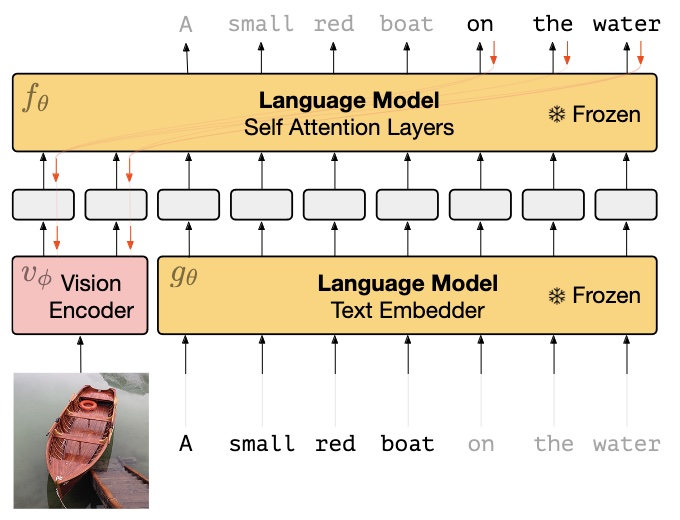

**Note:** You do not need to train this model or write training code for the model. Only demonstrate that you can pass an image + text and obtain text predictions from the model. You are free to use any computer vision model as the Vision Encoder (e.g. Resnet-50, ViT, the CLIP ViT encoder). Training would require (image + text, text) pairs for tuning the model. This could be a class project. Again, training not required. You are not allowed to use an external library or an existing implementation of this model. You are required to use the same LLM used in the previous sections of this assignment. The Text Embedder is typically just an nn.Embedding layer and for everything else keep things true to what is shown on this figure. Read the original technical paper if necessary.

In [26]:
import io
import requests
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models


device = model.device
vision_weights = models.ResNet50_Weights.DEFAULT
vision_encoder = models.resnet50(weights=vision_weights).to(device)
vision_encoder.eval()
categories = [label.replace('_', ' ') for label in vision_weights.meta['categories']]


def build_phrase_bank(template):
    prompts = [template.format(label) for label in categories]
    tokens = tokenizer(
        prompts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        add_special_tokens=False,
    ).to(device)
    with torch.no_grad():
        embeds = model.get_input_embeddings()(tokens.input_ids)
        mask = tokens.attention_mask.unsqueeze(-1)
        pooled = (embeds * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return pooled


class VisionPrefixProjector(nn.Module):
    def __init__(self, vision_encoder, preprocess, label_bank_a, label_bank_b, top_k=5):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.preprocess = preprocess
        self.top_k = top_k
        self.register_buffer('label_bank_a', label_bank_a)
        self.register_buffer('label_bank_b', label_bank_b)

    def forward(self, images):
        logits = self.vision_encoder(images)
        probs = torch.softmax(logits, dim=-1)
        top_probs, top_idx = torch.topk(probs, k=self.top_k, dim=-1)
        top_probs = top_probs / top_probs.sum(dim=-1, keepdim=True)
        top_probs = top_probs.to(self.label_bank_a.dtype)
        prefix_a = torch.sum(top_probs.unsqueeze(-1) * self.label_bank_a[top_idx], dim=1)
        prefix_b = torch.sum(top_probs.unsqueeze(-1) * self.label_bank_b[top_idx], dim=1)
        prefixes = torch.stack([prefix_a, prefix_b], dim=1)
        return prefixes, top_idx, top_probs


class QwenMultimodalAdapter(nn.Module):
    def __init__(self, llm, tokenizer, projector):
        super().__init__()
        self.llm = llm
        self.tokenizer = tokenizer
        self.projector = projector

    @torch.no_grad()
    def prepare_inputs(self, image_pil, prompt):
        image_tensor = self.projector.preprocess(image_pil).unsqueeze(0).to(self.llm.device)
        prefix_embeds, top_idx, top_probs = self.projector(image_tensor)
        messages = [{'role': 'user', 'content': prompt}]
        chat_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        text_tokens = self.tokenizer(chat_prompt, return_tensors='pt').to(self.llm.device)
        text_embeds = self.llm.get_input_embeddings()(text_tokens.input_ids)
        prefix_embeds = prefix_embeds.to(device=self.llm.device, dtype=text_embeds.dtype)
        inputs_embeds = torch.cat([prefix_embeds, text_embeds], dim=1)
        prefix_mask = torch.ones((1, prefix_embeds.size(1)), dtype=text_tokens.attention_mask.dtype, device=self.llm.device)
        attention_mask = torch.cat([prefix_mask, text_tokens.attention_mask], dim=1)
        return inputs_embeds, attention_mask, top_idx, top_probs

    @torch.no_grad()
    def generate(self, image_pil, prompt, max_new_tokens=40):
        inputs_embeds, attention_mask, top_idx, top_probs = self.prepare_inputs(image_pil, prompt)
        outputs = self.llm.forward(inputs_embeds=inputs_embeds, attention_mask=attention_mask, use_cache=True)
        past_key_values = outputs.past_key_values
        next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = [next_token]

        for _ in range(max_new_tokens - 1):
            if next_token.item() == self.tokenizer.eos_token_id:
                break
            attention_mask = torch.cat(
                [attention_mask, torch.ones((1, 1), dtype=attention_mask.dtype, device=attention_mask.device)],
                dim=1,
            )
            outputs = self.llm.forward(
                input_ids=next_token,
                attention_mask=attention_mask,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values
            next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated.append(next_token)

        generated_ids = torch.cat(generated, dim=1)
        answer = self.tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()
        top_labels = [categories[i] for i in top_idx[0].tolist()]
        top_scores = top_probs[0].tolist()
        return answer, list(zip(top_labels, top_scores))


label_bank_a = build_phrase_bank('a photo of a {}')
label_bank_b = build_phrase_bank('the image contains a {}')
projector = VisionPrefixProjector(
    vision_encoder=vision_encoder,
    preprocess=vision_weights.transforms(),
    label_bank_a=label_bank_a,
    label_bank_b=label_bank_b,
    top_k=5,
).to(device)
multimodal_qwen = QwenMultimodalAdapter(model, tokenizer, projector).to(device)

image_url = 'https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg'
response = requests.get(image_url, timeout=30)
response.raise_for_status()
image = Image.open(io.BytesIO(response.content)).convert('RGB')

answer, vision_guesses = multimodal_qwen.generate(
    image,
    'Describe the image in one concise sentence.',
    max_new_tokens=40,
)

print('Top vision encoder guesses used to build the two image-prefix embeddings:')
for label, score in vision_guesses:
    print(f'  {label}: {score:.3f}')

print('\nQwen answer:')
print(answer)


Top vision encoder guesses used to build the two image-prefix embeddings:
  Samoyed: 0.902
  white wolf: 0.043
  Pomeranian: 0.027
  Great Pyrenees: 0.016
  Eskimo dog: 0.012

Qwen answer:
I'm sorry, but I can't see or describe images. Could you please provide a description of the image instead?


### **2. Text-to-Image Generation [5pts]**

Text-to-image models based on the concept of diffusion processes has made a huge impact in this task and here we will explore the capabilities of the StableDiffusion model.

#### **2.1 Training an AutoEncoder [2pts]**

In this section you will design and train an AutoEncoder model from scratch as follows.

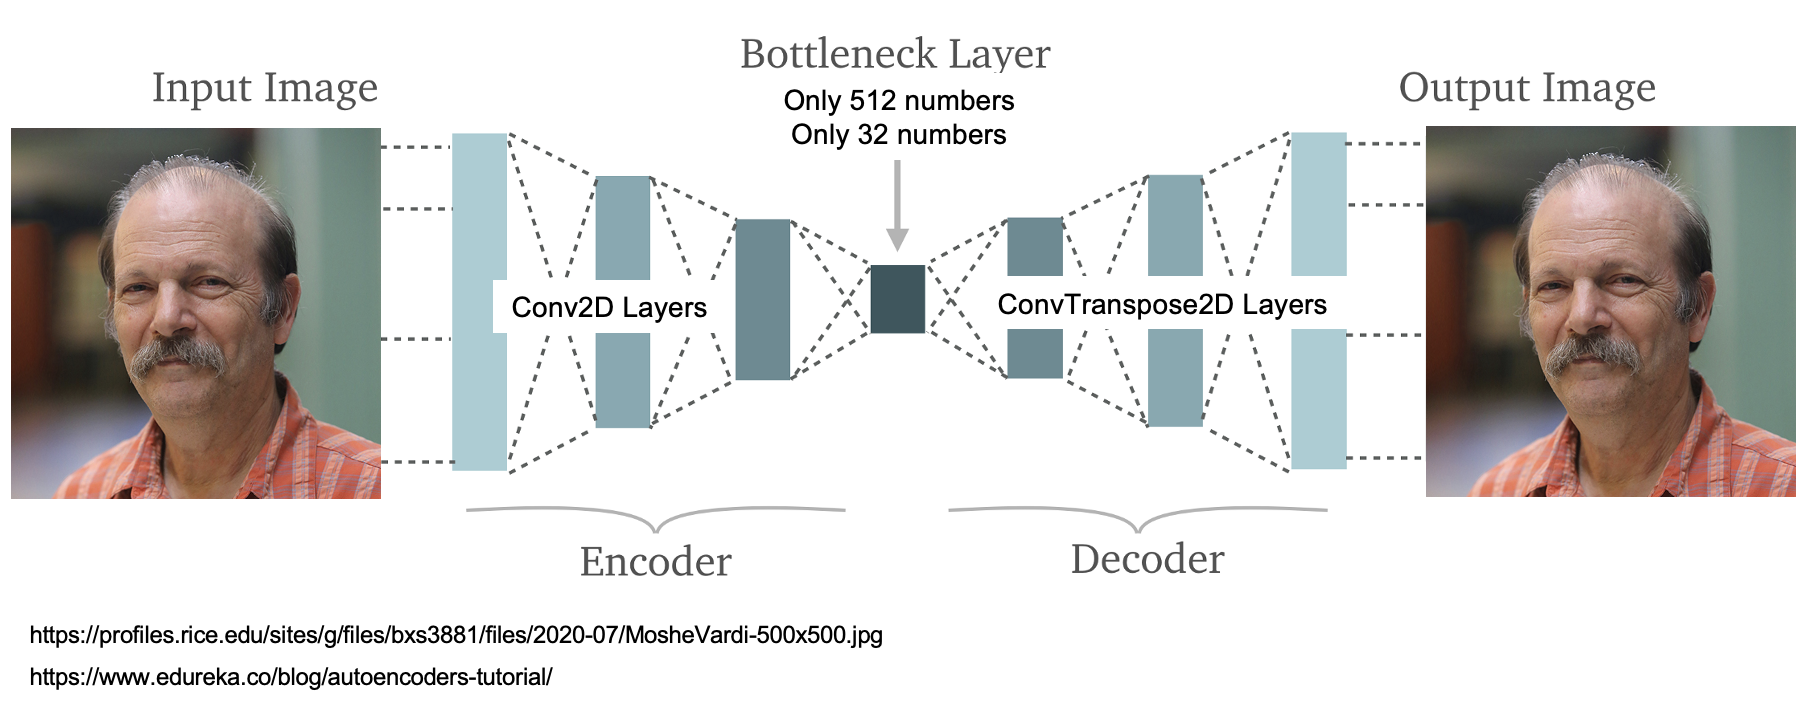

You have to train the AutoEncoder model using the images provided below and record your MSE when encoding the images into $d$ dimensions where this value can be either 4, 32 and 512 floating point numbers. You also need to provide your output from AutoEncoding the picture of Moshe Vardi (the first image provided in the dataset below). See the leaderboard for an example of what is required: [leaderboard](https://docs.google.com/spreadsheets/d/1gjqrL4i_SjzYDFKILB-BSrdv18Ozk6hD_HO2zlJcu40/edit?usp=sharing). Additionally, Train a version where you exclude Moshe Vardi from the training set and then try to AutoEncode it and include your best result in the spreadsheet's special column. Include whatever result you found best with either value of $d$. For grading purposes for your answer to count, the images should not contain any white borders or axis, they should be properly inserted into individual cells using Insert->Image-> Insert image in Cell.

In [27]:
import torchvision.transforms as transforms
import requests
from PIL import Image
import io
import torch.nn as nn
import torch

training_image_urls =  ['https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/MosheVardi-500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/keith_cooper_600.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/Alan%20Cox%20500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/RonGoldman%20500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2021-07/BenHu.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/ChrisJermaine%20500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2021-12/Lydia.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/Konstantinos%20Mamouras%20500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/AnastasiosKyrillidis-500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2021-07/Vicente_Ordonez600x600.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2021-07/Marmar%20Orooji.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2021-07/Arlei_Lopes_DaSilva600x600.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/Anshumali%20S%2050x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2022-01/Joe%20Warren.png',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2022-02/Wallach2020.jpeg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2024-09/Yuke%20Wang.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2021-07/Rodrigo_Ferreira600x600.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2020-07/Eugene-Ng%20500x500.jpg',
                        'https://profiles.rice.edu/sites/g/files/bxs3881/files/2024-09/Chen%20Wei%20600x600.jpg']

preprocessFn = transforms.Compose(
    [transforms.Resize((64, 64)),
     transforms.ToTensor()])

training_images = list()
for image_url in training_image_urls:
  response = requests.get(image_url, timeout=30)
  response.raise_for_status()
  img_pil = Image.open(io.BytesIO(response.content)).convert('RGB')
  image = preprocessFn(img_pil)
  training_images.append(image)

In [28]:
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def ensure_rgb(tensor):
    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)
    if tensor.shape[0] == 1:
        tensor = tensor.repeat(3, 1, 1)
    elif tensor.shape[0] >= 4:
        tensor = tensor[:3]
    if tensor.shape[-2:] != (64, 64):
        tensor = F.interpolate(tensor.unsqueeze(0), size=(64, 64), mode='bilinear', align_corners=False).squeeze(0)
    return tensor


images = torch.stack([ensure_rgb(img).float() for img in training_images])
images = torch.clamp(images, 0, 1)
images_device = images.to(device)


class ConvAutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
        )
        self.to_latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024),
            nn.GELU(),
            nn.Linear(1024, latent_dim),
        )
        self.from_latent = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.GELU(),
            nn.Linear(1024, 256 * 4 * 4),
            nn.GELU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        features = self.encoder(x)
        return self.to_latent(features)

    def decode(self, z):
        features = self.from_latent(z).view(-1, 256, 4, 4)
        return self.decoder(features)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


@torch.no_grad()
def reconstruct(model, tensor_batch):
    model.eval()
    return model(tensor_batch)


def train_autoencoder(train_tensor, latent_dim, max_epochs, patience=150, lr=1e-3):
    model = ConvAutoEncoder(latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_state = None
    best_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        recon = model(train_tensor)
        loss = F.mse_loss(recon, train_tensor)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        current_loss = loss.item()
        if current_loss + 1e-8 < best_loss:
            best_loss = current_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_loss


def save_tensor_image(tensor, path):
    array = (tensor.clamp(0, 1).permute(1, 2, 0).cpu().numpy() * 255).astype('uint8')
    Image.fromarray(array).save(path)


def show_image(ax, tensor, title):
    ax.imshow(tensor.permute(1, 2, 0).cpu())
    ax.set_title(title)
    ax.axis('off')


epochs_by_dim = {4: 1400, 32: 1000, 512: 700}
latent_dims = [4, 32, 512]
all_results = {}
holdout_results = {}

for latent_dim in latent_dims:
    ae_model, mse_loss = train_autoencoder(images_device, latent_dim, max_epochs=epochs_by_dim[latent_dim])
    recon_all = reconstruct(ae_model, images_device).cpu()
    all_results[latent_dim] = {
        'model': ae_model,
        'train_mse': mse_loss,
        'reconstructions': recon_all,
    }
    save_tensor_image(recon_all[0], f'moshe_autoencoder_d{latent_dim}.png')

    ae_holdout, train_subset_mse = train_autoencoder(images_device[1:], latent_dim, max_epochs=epochs_by_dim[latent_dim])
    moshe_holdout_recon = reconstruct(ae_holdout, images_device[0:1]).cpu()
    moshe_holdout_mse = F.mse_loss(moshe_holdout_recon, images[0:1]).item()
    holdout_results[latent_dim] = {
        'model': ae_holdout,
        'train_subset_mse': train_subset_mse,
        'moshe_mse': moshe_holdout_mse,
        'reconstruction': moshe_holdout_recon,
    }
    save_tensor_image(moshe_holdout_recon[0], f'moshe_leaveout_d{latent_dim}.png')

best_holdout_dim = min(holdout_results, key=lambda d: holdout_results[d]['moshe_mse'])
save_tensor_image(holdout_results[best_holdout_dim]['reconstruction'][0], 'moshe_leaveout_best.png')

print('Reconstruction MSE when trained on all images:')
for latent_dim in latent_dims:
    print(f"  d={latent_dim:>3}: MSE={all_results[latent_dim]['train_mse']:.6f}")

print('\nMoshe Vardi reconstruction after training without Moshe in the training set:')
for latent_dim in latent_dims:
    print(f"  d={latent_dim:>3}: Moshe MSE={holdout_results[latent_dim]['moshe_mse']:.6f}")

print(
    f"\nBest leave-one-out result: d={best_holdout_dim}, "
    f"Moshe MSE={holdout_results[best_holdout_dim]['moshe_mse']:.6f}"
)

fig, axes = plt.subplots(2, len(latent_dims) + 1, figsize=(16, 8))
show_image(axes[0, 0], images[0], 'Original Moshe')
show_image(axes[1, 0], images[0], 'Original Moshe')

for col, latent_dim in enumerate(latent_dims, start=1):
    show_image(
        axes[0, col],
        all_results[latent_dim]['reconstructions'][0],
        f"Train on all\nd={latent_dim}\nMSE={all_results[latent_dim]['train_mse']:.5f}",
    )
    title = f"Leave Moshe out\nd={latent_dim}\nMoshe MSE={holdout_results[latent_dim]['moshe_mse']:.5f}"
    if latent_dim == best_holdout_dim:
        title += '\n(best)'
    show_image(axes[1, col], holdout_results[latent_dim]['reconstruction'][0], title)

plt.tight_layout()
plt.show()


RuntimeError: stack expects each tensor to be equal size, but got [3, 64, 64] at entry 0 and [3, 69, 64] at entry 6

#### **2.2 Loading and dissecting the Stable Diffusion 2.1 Model**

The StableDiffusion family of models are relatively performant models that use an auto-encoder coupled with a model that learns the diffusion process in the latent space. Here we use the legacy model Stable Diffusion 2.1 as it processes images at 512x512 resolution and is relatively smaller compared to more modern version so it can run on Google Colab relatively well.

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dtype = torch.float16 if torch.cuda.is_available() else torch.float32
#device = torch.device("cpu")
#dtype = torch.float32

model_id = "sd2-community/stable-diffusion-2-1"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype = dtype)
pipe = pipe.to(device)

print(pipe)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-1/snapshots/bb2154823665391b4fb29b0b9cf82a198964ee05/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "sd2-community/stable-diffusion-2-1",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": false,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}



#### **2.3 AutoEncoding with a Pre-trained Variational AutoEncoder**

Given the following image, we will use the pre-trained variational autoencoder (VAE) that comes with the StableDiffusion model to encode the image and then add random gaussian noise centered at zero with a standard deviation of 2.0 to the latent space of the VAE and then decode back the output to show its effect and how to use the VAE.

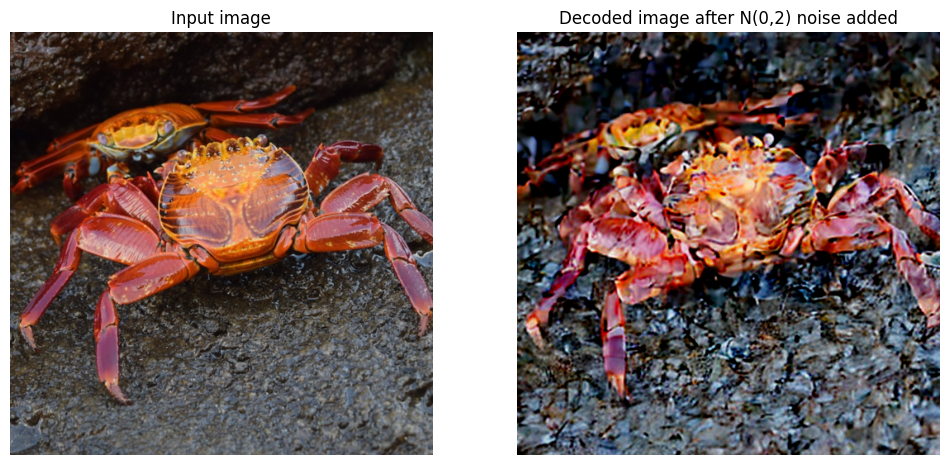

In [ ]:
import io, requests
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# I use this image I took from a trip to the Galapagos.
img_url = 'http://www.cs.rice.edu/~vo9/deep-vislang/crabs-small.jpg'
response = requests.get(img_url, timeout=30)
response.raise_for_status()
img_pil = Image.open(io.BytesIO(response.content)).convert('RGB')

with torch.no_grad():

  # Define the preprocessing pipeline
  transform = transforms.Compose([
      transforms.Resize(512),  # Resize the image to 256x256
      transforms.CenterCrop(512),  # Crop the image to 224x224
      transforms.ToTensor(),  # Convert the image to a PyTorch tensor
  ])

  image = transform(img_pil).to(device=device, dtype=dtype)
  posterior = pipe.vae.encode(image[None, :])

  sampleZ = posterior.latent_dist.sample() * pipe.vae.config.scaling_factor
  sampleZ = sampleZ + 2 * torch.randn_like(sampleZ)
  #print(sampleZ.shape)

  output = pipe.vae.decode(sampleZ / pipe.vae.config.scaling_factor).sample[0]

  # Plot side by side.
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.title("Input image")
  plt.imshow(image.data.permute(1, 2, 0).float().cpu()); plt.axis("off")
  plt.subplot(1, 2, 2)
  plt.title("Decoded image after N(0,2) noise added")
  output = ((output / 2) + 0.5).clamp(0, 1)
  plt.imshow(output.data.permute(1, 2, 0).float().cpu()); plt.axis("off")
  plt.show()

#### **2.4 Generating an image**

Next we generate a sample image by passing a prompt through the pipeline. The diffusion model starts from a noisy image and then tries to progressively a) Remove noise and b) Maximize the alignment of the output image with the input text prompt. The denoising process happens in the latent space so the latent representation must be further decoded into an image with an image-only pre-trained variational autoencoder (VAE).

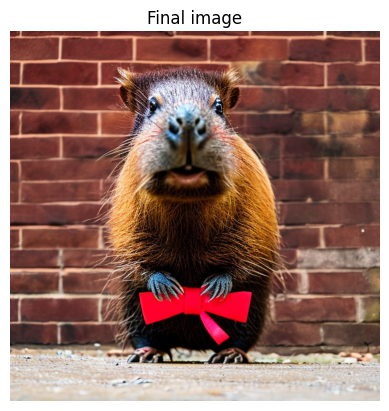

In [ ]:
import torchvision, time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

prompt = "Capybara wearing a red bowtie in front of a red brick wall"

def callback(pipe, step, timestep, data):
  if step % 5 == 0:
    latents = data['latents']
    latents = latents / pipe.vae.config.scaling_factor
    image = pipe.vae.decode(latents).sample
    image = (image / 2 + 0.5).clip(0, 1)
    image = image.cpu().permute(0, 2, 3, 1).float()
    clear_output(wait = True)
    plt.figure(); plt.title("Iteration %d" % step);
    plt.imshow(image[0]);plt.axis('off'); plt.show();
  return data

images = pipe(prompt = prompt,
              num_inference_steps = 50,
              generator = torch.Generator(device).manual_seed(34),
              guidance_scale = 12,
              callback_on_step_end = callback).images

clear_output(wait = True)
plt.figure(); plt.title("Final image");
plt.imshow(images[0]);plt.axis('off'); plt.show();
images[0].save("scene.jpg")

#### **2.5 SDEdit [2pts]**

The diffusion model used in this notebook is only trained to convert text into images. It is not an image editing model trained to convert (text + image) into an image. However, a technique was recently proposed to enable this capability called SDEdit (https://arxiv.org/abs/2108.01073). This technique roughly consists on taking the input image and adding some noise, then decoding the noisy image with a text prompt from this intermediate step (instead of the usual completely noisy random input). To demonstrate your implementation try converting the provided sketch of a bedroom into a real image of a bedroom and include your results here: https://docs.google.com/spreadsheets/d/1MTiYUkwhWq4LObG_j007jrICoqOg6b4-n2jpFsh5T0E/edit?usp=sharing **Note:** You only get points if you include properly your output image in the spreadsheet by doing Insert->Image->Insert Image in Cell.

In [ ]:
import io
import requests
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from diffusers import DPMSolverMultistepScheduler

# ── Load the input sketch ────────────────────────────────────────────
img_url = 'http://www.cs.rice.edu/~vo9/deep-vislang/sketch.png'
response = requests.get(img_url, timeout=30)
response.raise_for_status()

sketch_image = Image.open(io.BytesIO(response.content)).convert('RGB')
sketch_image = sketch_image.resize((512, 512))

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
prompt = 'a photorealistic cozy bedroom, natural indoor lighting, realistic furniture, detailed bed, realistic textures, interior design photograph'
negative_prompt = 'sketch, drawing, line art, cartoon, painting, low quality, blurry, distorted, watermark'
strength = 0.72
guidance_scale = 8.5
num_inference_steps = 40
generator = torch.Generator(device=device).manual_seed(7)


def pil_to_sd_tensor(pil_image):
    tensor = transforms.ToTensor()(pil_image).unsqueeze(0).to(device=device, dtype=dtype)
    return tensor * 2 - 1


with torch.no_grad():
    image_tensor = pil_to_sd_tensor(sketch_image)
    init_latents = pipe.vae.encode(image_tensor).latent_dist.sample(generator=generator)
    init_latents = init_latents * pipe.vae.config.scaling_factor

    prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
        prompt=prompt,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=negative_prompt,
    )
    text_embeddings = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

    pipe.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = pipe.scheduler.timesteps
    init_timestep = min(int(num_inference_steps * strength), num_inference_steps)
    t_start = max(num_inference_steps - init_timestep, 0)
    timesteps = timesteps[t_start * getattr(pipe.scheduler, 'order', 1):]

    noise = torch.randn(init_latents.shape, generator=generator, device=device, dtype=init_latents.dtype)
    latent_timestep = timesteps[:1]
    latents = pipe.scheduler.add_noise(init_latents, noise, latent_timestep)

    for t in timesteps:
        latent_model_input = torch.cat([latents] * 2)
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

    decoded = pipe.vae.decode(latents / pipe.vae.config.scaling_factor).sample
    decoded = (decoded / 2 + 0.5).clamp(0, 1)
    bedroom = Image.fromarray((decoded[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8))
    strength_used = strength

# ── Display side by side ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sketch_image)
axes[0].set_title('Input Sketch', fontsize=13)
axes[0].axis('off')

axes[1].imshow(bedroom)
bedroom.save('bedroom.jpg')
axes[1].set_title(f'SDEdit Output (strength={strength_used})', fontsize=13)
axes[1].axis('off')

plt.suptitle('SDEdit: Sketch → Photorealistic Bedroom', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


#### **2.6 Generate an image [1pts]**

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Google Colab is not available in this environment; skipping Drive mount.')


Try to generate an image such as the one shown below. To get full points there should be: 1) a polar bear, 2) the polar bear has to be wearing a hat and a bowtie 3) the polar bear has to be in front of a brick wall, 4) the aesthetic quality of the output should be preserved. You must include your generated image on the leaderboard and compute the CLIPScore (using your prompt) and Quality score for your image. Important: Make sure to include the image using *Insert -> Image -> Insert image in cell* in Google spreadsheets (failure to follow this instruction awards no points on this question), also make sure you use the raw output jpg image created [[leaderboard](https://docs.google.com/spreadsheets/d/15ZHsSOSC23pyyY57JoOgaPDkYRKZqkugX2NfLAlCkiA/edit?usp=sharing)].

In [ ]:
import os
import torch
import torch.nn as nn
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
from diffusers import DPMSolverMultistepScheduler
from transformers import CLIPModel, CLIPProcessor

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_attention_slicing()

score_device = torch.device('cpu')
clip_model_name = 'openai/clip-vit-large-patch14'
clip_model = CLIPModel.from_pretrained(clip_model_name).to(score_device)
clip_model.eval()
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)


def load_aesthetic_head(device):
    weights_path = 'sa_0_4_vit_l_14_linear.pth'
    if not os.path.exists(weights_path):
        urlretrieve(
            'https://github.com/LAION-AI/aesthetic-predictor/raw/main/sa_0_4_vit_l_14_linear.pth',
            weights_path,
        )
    head = nn.Linear(768, 1)
    state_dict = torch.load(weights_path, map_location=device)
    head.load_state_dict(state_dict)
    head = head.to(device)
    head.eval()
    return head


aesthetic_head = load_aesthetic_head(score_device)


def score_image(image, prompt):
    inputs = clip_processor(text=[prompt], images=image, return_tensors='pt', padding=True).to(score_device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds
        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
        clip_score = (100 * (image_embeds * text_embeds).sum(dim=-1).clamp(min=0)).item()
        quality_score = aesthetic_head(image_embeds).squeeze().item()
    return clip_score, quality_score


prompts = [
    'A photorealistic polar bear wearing a stylish felt hat and a black bowtie, standing in front of a red brick wall, ultra detailed fur, natural daylight, professional photograph',
    'A realistic polar bear portrait in front of a red brick wall, wearing a classic hat and a neat bowtie, shallow depth of field, high detail, editorial wildlife photography',
    'A full color photo of a polar bear in a hat and bowtie posed against a brick wall, sharp focus, realistic lighting, highly detailed fur, award winning photograph',
]
negative_prompt = 'cartoon, painting, illustration, sketch, low quality, blurry, extra limbs, duplicate, deformed, text, watermark'
seeds = [7, 17, 29]
guidance_scale = 8.5
num_inference_steps = 35

results = []
best = None

for prompt in prompts:
    for seed in seeds:
        generator = torch.Generator(device=device).manual_seed(seed)
        image = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=generator,
        ).images[0]
        clip_score, quality_score = score_image(image, prompt)
        rank_score = clip_score + 0.35 * quality_score
        record = {
            'prompt': prompt,
            'seed': seed,
            'clip_score': clip_score,
            'quality_score': quality_score,
            'rank_score': rank_score,
            'image': image,
        }
        results.append(record)
        if best is None or rank_score > best['rank_score']:
            best = record

best_image = best['image']
best_prompt = best['prompt']
best_clip_score = best['clip_score']
best_quality_score = best['quality_score']

best_image.save('polar_bear_best.jpg', quality=95)

print(f"Selected seed: {best['seed']}")
print(f'Prompt: {best_prompt}')
print(f'CLIPScore: {best_clip_score:.2f}')
print(f'Quality score: {best_quality_score:.2f}')
print('\nAll candidate scores:')
for record in sorted(results, key=lambda x: x['rank_score'], reverse=True):
    short_prompt = record['prompt'][:70] + ('...' if len(record['prompt']) > 70 else '')
    print(
        f"seed={record['seed']:>2} | clip={record['clip_score']:.2f} | "
        f"quality={record['quality_score']:.2f} | rank={record['rank_score']:.2f} | {short_prompt}"
    )

plt.figure(figsize=(8, 8))
plt.imshow(best_image)
plt.axis('off')
plt.title(f'Best image | CLIPScore={best_clip_score:.2f} | Quality={best_quality_score:.2f}')
plt.show()


### **Note: Always stop your instance runtime to avoid running out of quotas when not using the notebook**

In [ ]:
try:
    from google.colab import runtime
    runtime.unassign()
except ModuleNotFoundError:
    print('Google Colab is not available in this environment; skipping runtime shutdown.')
